# Mikayel Harutyunyan

## **DS223 - Marketing Analytics**
## **Homework 3 - Survival Analysis & Customer Lifetime Value**

### Setup & Data Loading

In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from lifelines import (
    # Univariate
    WeibullFitter, LogNormalFitter, LogLogisticFitter,
    ExponentialFitter, GeneralizedGammaFitter,
    KaplanMeierFitter, PiecewiseExponentialFitter,
    SplineFitter, MixtureCureFitter,
    NelsonAalenFitter, BreslowFlemingHarringtonFitter,
    
    # Regression (AFT)
    WeibullAFTFitter, LogNormalAFTFitter, LogLogisticAFTFitter,
    GeneralizedGammaRegressionFitter, CoxPHFitter,
    PiecewiseExponentialRegressionFitter,
)

df = pd.read_csv('telco.csv')
print(df.shape)
df.head(3)

(1000, 15)


,ID,region,tenure,age,marital,address,income,ed,retire,gender,voice,internet,forward,custcat,churn
0,1,Zone 2,13,44,Married,9,64,College degree,No,Male,No,No,Yes,Basic service,Yes
1,2,Zone 3,11,33,Married,7,136,Post-undergraduate degree,No,Male,Yes,No,Yes,Total service,Yes
2,3,Zone 3,68,52,Married,24,116,Did not complete high school,No,Female,No,No,No,Plus service,No


### Data Preparation

In [128]:
# Converting to numeric
df['event'] = (df['churn'] == 'Yes').astype(int)

# Monthly margin derived from the slides
MM = 1300

# One-hot encode categorical features
cat_cols = ['region','marital','ed','retire','gender','voice','internet','forward','custcat']
df_enc = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=int)
df = df.reset_index(drop=True)
df_enc = df_enc.reset_index(drop=True)

exclude = ['ID', 'churn', 'event', 'tenure']
feature_cols = [c for c in df_enc.columns if c not in exclude]

print(f"Churn rate: {df['event'].mean():.1%}")
print(f"Tenure range: {df['tenure'].min()}–{df['tenure'].max()} months")
print(f"Features: {len(feature_cols)}")

Churn rate: 27.4%
Tenure range: 1–72 months
Features: 18


### Kaplan-Meier Baseline

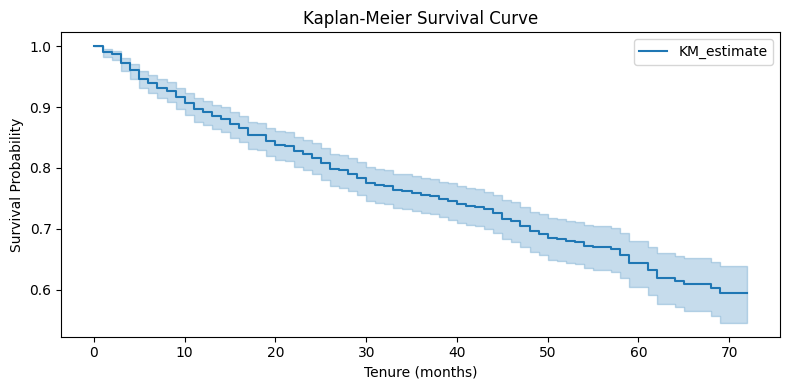

Median survival time: inf months


In [129]:
kmf = KaplanMeierFitter()
kmf.fit(df['tenure'], event_observed=df['event'])

plt.figure(figsize=(8, 4))
kmf.plot_survival_function()
plt.title('Kaplan-Meier Survival Curve')
plt.xlabel('Tenure (months)')
plt.ylabel('Survival Probability')
plt.tight_layout()
plt.show()
print(f"Median survival time: {kmf.median_survival_time_} months")

## Univariate AFT Models

Fit all parametric distributions without covariates, compare AIC, and visualize all survival curves on one plot.

In [130]:
uni_fitters = {
    'Weibull': WeibullFitter(),
    'LogNormal': LogNormalFitter(),
    'LogLogistic': LogLogisticFitter(),
    'Exponential': ExponentialFitter(),
    'GeneralizedGamma': GeneralizedGammaFitter(),
    'PiecewiseExponential': PiecewiseExponentialFitter(breakpoints=[12, 36, 60]),
    'Spline': SplineFitter(knot_locations=[6, 24, 48, 66]),
    'MixtureCure': MixtureCureFitter(base_fitter=WeibullFitter()),
    'BreslowFH': BreslowFlemingHarringtonFitter(),
    'NelsonAalen': NelsonAalenFitter(),
}

for name, model in uni_fitters.items():
    model.fit(df['tenure'], event_observed=df['event'])

### Univariate Model Comparison

In [131]:
uni_comparison = pd.DataFrame({
    'Model': list(uni_fitters.keys()),
    'AIC': [round(m.AIC_, 2) if hasattr(m, 'AIC_') else np.nan for m in uni_fitters.values()],
    'Log-Likelihood': [round(m.log_likelihood_, 2) if hasattr(m, 'log_likelihood_') else np.nan for m in uni_fitters.values()]
}).sort_values('AIC', na_position='last').reset_index(drop=True)

print(uni_comparison.to_string(index=False))

               Model     AIC  Log-Likelihood
           LogNormal 3209.04        -1602.52
    GeneralizedGamma 3211.01        -1602.50
              Spline 3213.25        -1602.63
         LogLogistic 3214.42        -1605.21
         Exponential 3215.96        -1606.98
PiecewiseExponential 3216.24        -1604.12
             Weibull 3216.86        -1606.43
         MixtureCure 3217.36        -1605.68
           BreslowFH     NaN             NaN
         NelsonAalen     NaN             NaN


### Univariate Survival Curves Plot

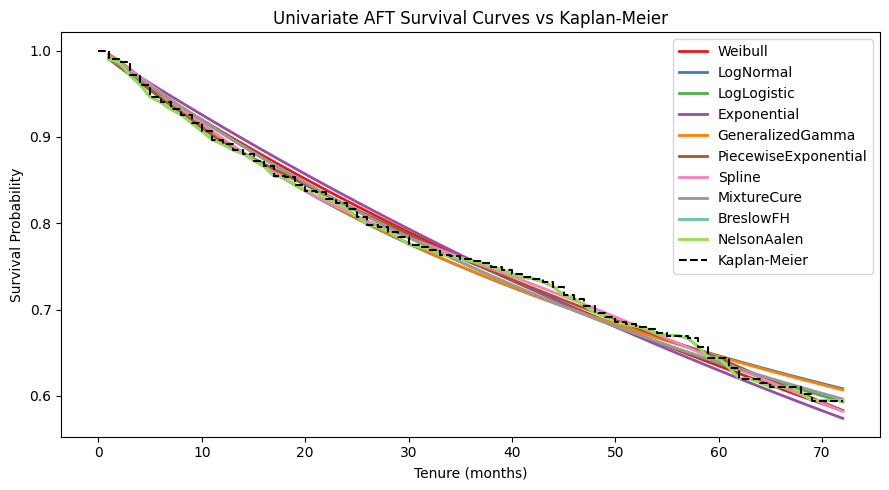

In [132]:
colors = ['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00',
          '#a65628','#f781bf','#999999','#66c2a5',"#94df4d"]

time_points = np.arange(1, 73)

plt.figure(figsize=(9, 5))
for (name, model), color in zip(uni_fitters.items(), colors):
    if isinstance(model, NelsonAalenFitter):
        ch = model.cumulative_hazard_at_times(time_points)
        sf = np.exp(-ch.values)
    else:
        sf = model.survival_function_at_times(time_points).values.flatten()
    plt.plot(time_points, sf, label=name, color=color, linewidth=2)

kmf.plot_survival_function(ax=plt.gca(), ci_show=False, label='Kaplan-Meier',
                            color='black', linestyle='--', linewidth=1.5)
plt.title('Univariate AFT Survival Curves vs Kaplan-Meier')
plt.xlabel('Tenure (months)')
plt.ylabel('Survival Probability')
plt.legend()
plt.tight_layout()
plt.show()

## Regression AFT Models

Fitting all parametric AFT regression models with all features.

In [133]:
model_data = df_enc[feature_cols + ['tenure', 'event']].copy()

reg_fitters = {
    'WeibullAFT': WeibullAFTFitter(penalizer=0.01),
    'LogNormalAFT': LogNormalAFTFitter(penalizer=0.01),
    'LogLogisticAFT': LogLogisticAFTFitter(penalizer=0.01),
    'GeneralizedGammaAFT': GeneralizedGammaRegressionFitter(penalizer=1.0),
    'CoxPH': CoxPHFitter(),
    'PiecewiseExponentialReg': PiecewiseExponentialRegressionFitter(breakpoints=[12, 36, 60]),
}

# GeneralizedGamma needs SLSQP to converge
reg_fitters['GeneralizedGammaAFT']._scipy_fit_method = 'SLSQP'

for name, model in reg_fitters.items():
    model.fit(model_data, duration_col='tenure', event_col='event')

Retrieved SLSQP from: https://docs.scipy.org/doc/scipy/reference/optimize.minimize-slsqp.html

### Regression Model Comparison

In [134]:
def get_aic(m):
    try:
        return round(m.AIC_, 2)
    except:
        return round(m.AIC_partial_, 2)

reg_comparison = pd.DataFrame({
    'Model': list(reg_fitters.keys()),
    'AIC': [get_aic(m) for m in reg_fitters.values()],
    'Log-Likelihood': [round(m.log_likelihood_, 2) for m in reg_fitters.values()]
}).sort_values('AIC').reset_index(drop=True)

print(reg_comparison.to_string(index=False))
print(f"\nBest regression model: {reg_comparison.iloc[0]['Model']}")

                  Model     AIC  Log-Likelihood
           LogNormalAFT 2966.44        -1463.22
         LogLogisticAFT 2968.53        -1464.26
             WeibullAFT 2974.15        -1467.07
PiecewiseExponentialReg 2976.75        -1412.37
                  CoxPH 3272.76        -1618.38
    GeneralizedGammaAFT 3953.44        -1922.72

Best regression model: LogNormalAFT


### Regression Survival Curves Plot

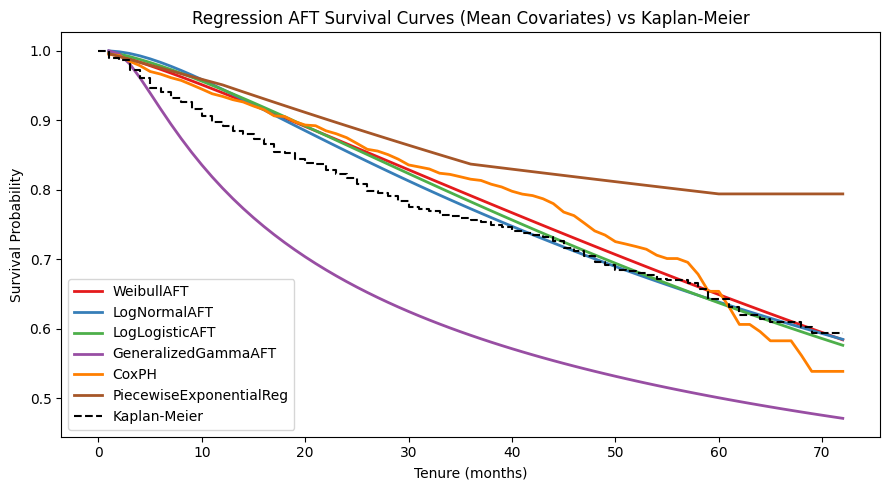

In [135]:
mean_row = model_data[feature_cols].mean().to_frame().T
colors_reg = ['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00','#a65628']

plt.figure(figsize=(9, 5))
for (name, model), color in zip(reg_fitters.items(), colors_reg):
    sf = model.predict_survival_function(mean_row, times=time_points)
    plt.plot(time_points, sf.values.flatten(), label=name, color=color, linewidth=2)

kmf.plot_survival_function(ax=plt.gca(), ci_show=False, label='Kaplan-Meier',
                            color='black', linestyle='--', linewidth=1.5)
plt.title('Regression AFT Survival Curves (Mean Covariates) vs Kaplan-Meier')
plt.xlabel('Tenure (months)')
plt.ylabel('Survival Probability')
plt.legend()
plt.tight_layout()
plt.show()

#### LogNormalAFT has the best AIC, so it's the natural choice statistically. It also makes intuitive sense for telecom, as churn risk isn't constant over time. New customers are more likely to leave early, while those who stay long enough tend to stick around. LogNormal captures this pattern well.

### Feature Selection (with p < 0.05)

In [136]:
best_reg = reg_fitters['LogNormalAFT']

mu_summary = best_reg.summary.xs('mu_', level=0)
pvals = mu_summary['p']
sig_features = pvals[(pvals < 0.05) & (pvals.index != 'Intercept')].index.tolist()

print(f"Significant features ({len(sig_features)}):")
for f in sig_features:
    coef = mu_summary.loc[f, 'coef']
    print(f"{f:<35s}  coef={coef:+.3f}  p={pvals[f]:.4f}")

Significant features (8):
address                              coef=+0.041  p=0.0000
age                                  coef=+0.032  p=0.0000
custcat_E-service                    coef=+0.967  p=0.0000
custcat_Plus service                 coef=+0.781  p=0.0001
custcat_Total service                coef=+0.979  p=0.0000
internet_Yes                         coef=-0.725  p=0.0000
marital_Unmarried                    coef=-0.443  p=0.0001
voice_Yes                            coef=-0.372  p=0.0197


## Final Model — LogNormal AFT (Significant Features Only)

In [137]:
final_data = df_enc[sig_features + ['tenure', 'event']].copy()

final_model = LogNormalAFTFitter(penalizer=0.01)
final_model.fit(final_data, duration_col='tenure', event_col='event')

print(f"Final AIC: {final_model.AIC_:.2f}")
print(f"Log-Likelihood: {final_model.log_likelihood_:.2f}")
final_model.print_summary()

Final AIC: 2955.75
Log-Likelihood: -1467.87


<lifelines.LogNormalAFTFitter: fitted with 1000 total observations, 726 right-censored observations>
             duration col = 'tenure'
                event col = 'event'
                penalizer = 0.01
   number of observations = 1000
number of events observed = 274
           log-likelihood = -1467.87
         time fit was run = 2026-05-06 20:10:32 UTC

---
                              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param  covariate                                                                                                              
mu_    address                0.04      1.04      0.01            0.03            0.06                1.03                1.06
       age                    0.04      1.04      0.01            0.02            0.05                1.02                1.05
       custcat_E-service      0.93      2.54      0.16            0.62            1.25                1.86                3.48
       custcat_Plus service   0.75      2.11      0.16            0.43            1.06                1.54                2.89
       custcat_Total service  0.87      2.40      0.19            0.49            1.26                1.64                3.51
       internet_Yes          -0.79      0.45      0.13           -1.05           -0.53                0.35                0.59
       marital_Unmarried     -0.44      0.65      0.11           -0.65           -0.22                0.52                0.80
       voice_Yes             -0.40      0.67      0.16           -0.71           -0.09                0.49                0.91
       Intercept              2.59     13.35      0.23            2.13            3.05                8.45               21.08
sigma_ Intercept              0.27      1.31      0.04            0.18            0.36                1.20                1.43

                              cmp to     z      p  -log2(p)
param  covariate                                           
mu_    address                  0.00  5.06 <0.005     21.20
       age                      0.00  5.93 <0.005     28.33
       custcat_E-service        0.00  5.81 <0.005     27.28
       custcat_Plus service     0.00  4.67 <0.005     18.34
       custcat_Total service    0.00  4.48 <0.005     17.06
       internet_Yes             0.00 -5.99 <0.005     28.86
       marital_Unmarried        0.00 -3.94 <0.005     13.56
       voice_Yes                0.00 -2.54   0.01      6.48
       Intercept                0.00 11.12 <0.005     93.00
sigma_ Intercept                0.00  6.02 <0.005     29.06
---
Concordance = 0.78
AIC = 2955.75
log-likelihood ratio test = 269.29 on 8 df
-log2(p) of ll-ratio test = 175.58

### Coefficient Interpretation

In AFT models, coefficients act on log(survival time), so
- **Positive coefficient** -> longer survival (lower churn risk)
- **Negative coefficient** -> shorter survival (higher churn risk)

In [138]:
coef_df = final_model.summary.xs('mu_', level=0)
coef_df = coef_df[coef_df.index != 'Intercept'][['coef', 'exp(coef)', 'p']].round(4)
print(coef_df.sort_values('coef', ascending=False).to_string())

                         coef  exp(coef)       p
covariate                                       
custcat_E-service      0.9322     2.5401  0.0000
custcat_Total service  0.8736     2.3955  0.0000
custcat_Plus service   0.7479     2.1125  0.0000
address                0.0419     1.0428  0.0000
age                    0.0357     1.0364  0.0000
voice_Yes             -0.3985     0.6713  0.0112
marital_Unmarried     -0.4360     0.6466  0.0001
internet_Yes          -0.7904     0.4537  0.0000


### CLV Calculation

In [139]:
T, r = 24, 0.10

surv_matrix = final_model.predict_survival_function(
    final_data[sig_features], times=np.arange(1, T + 1)
)
discount = np.array([1 / (1 + r / 12) ** (i - 1) for i in range(1, T + 1)])
discounted_surv = surv_matrix.values * discount[:, np.newaxis]

df['CLV'] = MM * discounted_surv.sum(axis=0)

print("CLV Summary ($):")
print(df['CLV'].describe().round(2))

CLV Summary ($):
count     1000.00
mean     25412.09
std       3045.37
min      10181.10
25%      23840.94
50%      26415.89
75%      27839.73
max      28405.62
Name: CLV, dtype: float64


### CLV Distribution

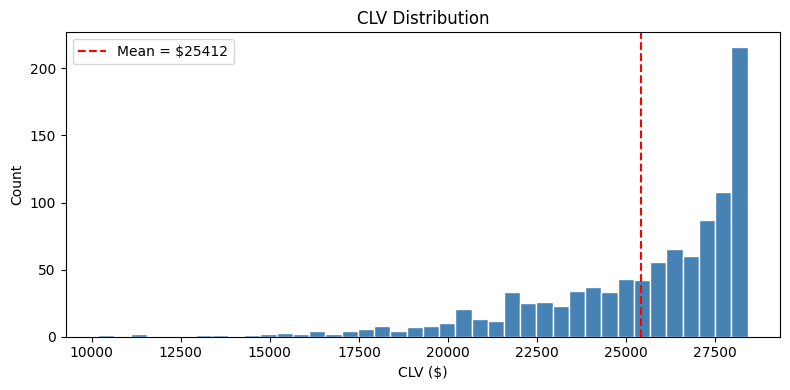

In [140]:
plt.figure(figsize=(8, 4))
plt.hist(df['CLV'], bins=40, color='steelblue', edgecolor='white')
plt.axvline(df['CLV'].mean(), color='red', linestyle='--',
            label=f"Mean = ${df['CLV'].mean():.0f}")
plt.title('CLV Distribution')
plt.xlabel('CLV ($)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

### Segment Exploration

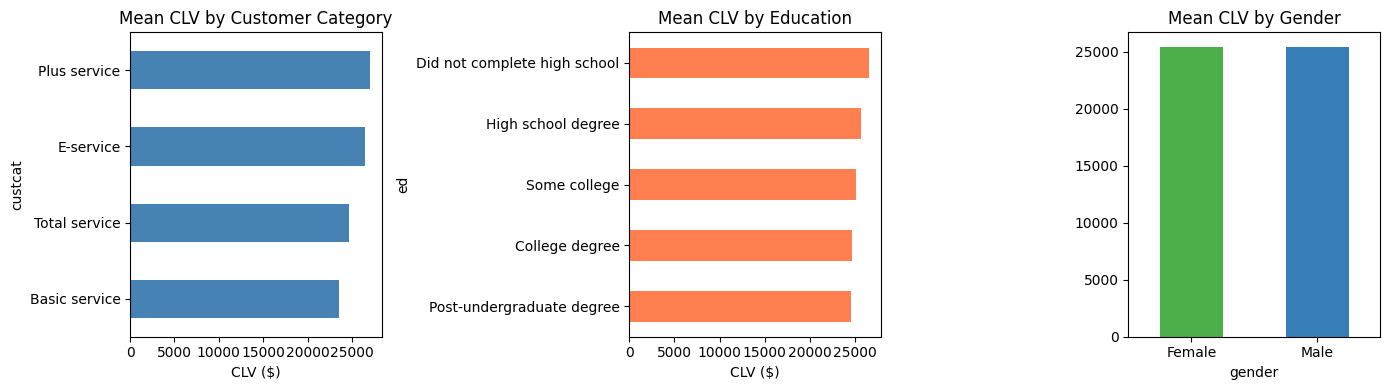

In [141]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

df.groupby('custcat')['CLV'].mean().sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Mean CLV by Customer Category')
axes[0].set_xlabel('CLV ($)')

df.groupby('ed')['CLV'].mean().sort_values().plot(
    kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Mean CLV by Education')
axes[1].set_xlabel('CLV ($)')

df.groupby('gender')['CLV'].mean().plot(
    kind='bar', ax=axes[2], color=['#4daf4a', '#377eb8'])
axes[2].set_title('Mean CLV by Gender')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### Quartile-based CLV segments

In [142]:
df['CLV_segment'] = pd.qcut(df['CLV'], q=4, labels=['Low', 'Medium', 'High', 'VIP'])

seg_summary = df.groupby('CLV_segment', observed=True).agg(
    n_customers=('CLV', 'count'),
    mean_clv=('CLV', 'mean'),
    mean_tenure=('tenure', 'mean'),
    churn_rate=('event', 'mean'),
    mean_income=('income', 'mean')
).round(2)

print(seg_summary.to_string())

             n_customers  mean_clv  mean_tenure  churn_rate  mean_income
CLV_segment                                                             
Low                  251  21028.37        20.33        0.47        43.11
Medium               249  25262.92        28.85        0.35        59.67
High                 250  27198.95        39.37        0.20        88.64
VIP                  250  28175.05        53.59        0.08       118.79


### Annual Retention Budget

In [143]:
# Active customers with under a 50% chance of staying over the next year.
surv_12 = final_model.predict_survival_function(
    final_data[sig_features], times=[12]
).iloc[0].values

df['surv_prob_12m'] = surv_12
at_risk = df[(df['event'] == 0) & (df['surv_prob_12m'] < 0.5)]

print(f"Total customers: {len(df)}")
print(f"Active (not churned): {(df['event']==0).sum()}")
print(f"At-risk within 12 months: {len(at_risk)}")
print(f"Total at-risk CLV: ${at_risk['CLV'].sum():.0f}")
print(f"Suggested retention budget: ${at_risk['CLV'].sum() * 0.1:.0f}  (10% of at-risk CLV)")

Total customers: 1000
Active (not churned): 726
At-risk within 12 months: 4
Total at-risk CLV: $56906
Suggested retention budget: $5691  (10% of at-risk CLV)


## Report

### Factors Affecting Churn Risk

The Log-Normal AFT model points to a fairly clear pattern in customer retention and churn. From my analysis, customers who have lived at the same address for a long time tend to stay longer, which is consistent with higher stability reducing churn, with exp(coef) = 1.04 per year. Age shows a similar effect in my results, where older subscribers churn less, also with exp(coef) = 1.04 per year. On the service side, I find that customers on Total, Plus, or E-service bundles stay about 2.1–2.5x longer than Basic service users, likely reflecting higher switching costs and stronger perceived value of bundled services. In contrast, having internet service increases churn risk substantially in my model (exp(coef) = 0.45), suggesting these customers are more informed about alternatives and more willing to switch providers. Unmarried customers (exp(coef) = 0.65) and those with voice add-ons (exp(coef) = 0.67) also show higher churn, which I think indicates lower long-term commitment or more transitional customer profiles.

### Most Valuable Segments, Retention Budget & Suggestions

Based on my analysis, a valuable customer, is one that combines long predicted survival time with high CLV, specifically older, address-stable subscribers on bundled plans. The segment analysis confirms this pattern: VIP customers (top CLV quartile) have a mean CLV of $28,175, churn rate of 8%, average tenure of 54 months, and average income of $119K, while Low segment customers have a mean CLV of $21,028, churn rate of 47%, and average tenure of 20 months. The overall mean CLV across all customers is $25,412. From the survival model, I identify 4 currently active customers with a predicted 12-month survival probability below 50%, corresponding to a total at-risk CLV pool of $56,906, which in my view implies a suggested annual retention budget of $5,691 (10% of at-risk CLV). For retention actions, I would prioritize upgrading Basic service subscribers into bundled plans to increase switching costs, focusing early-tenure engagement on new subscribers where churn risk is highest in the first 12 months, and targeting internet subscribers with tailored offers to cross-sell complementary services and shift them toward more stable bundled relationships.